Classe prédite : [1]


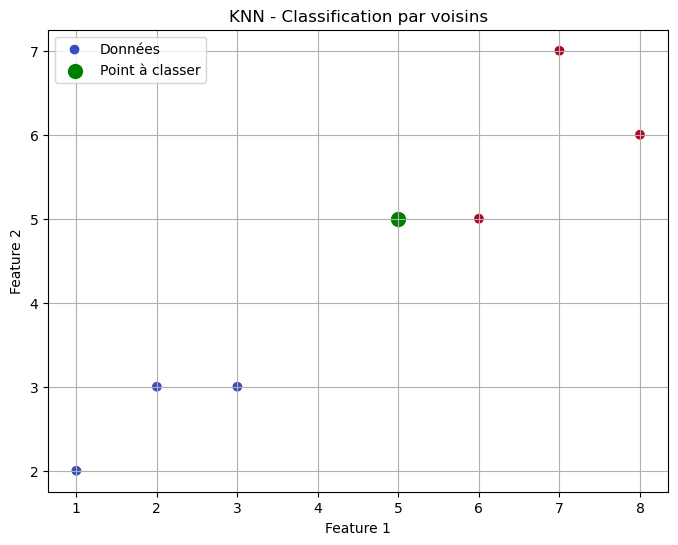

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# =========================================================
# 1. DÉFINITION DU DATASET
# =========================================================
# On considère un problème de classification supervisée.
# Chaque point est défini par deux caractéristiques (X1, X2).
# Chaque point appartient à une classe (0 ou 1).

# Points du dataset (features)
X = np.array([
    [1, 2], [2, 3], [3, 3],      # Classe 0
    [6, 5], [7, 7], [8, 6]       # Classe 1
])

# Labels associés
y = np.array([0, 0, 0, 1, 1, 1])


# =========================================================
# 2. PRINCIPE DU KNN
# =========================================================
# KNN = K-Nearest Neighbors (k plus proches voisins)
#
# Contrairement au SVM :
# - KNN n'apprend pas un modèle mathématique
# - Il mémorise simplement les données
#
# Lors d'une prédiction :
# 1. Calculer la distance entre le nouveau point et tous les points
# 2. Sélectionner les k points les plus proches
# 3. Faire un vote majoritaire
# 4. Retourner la classe dominante

class KNN:

    def __init__(self, k=3):
        # k : nombre de voisins à considérer
        # petit k → sensible au bruit
        # grand k → plus stable mais moins précis localement
        self.k = k

    # =====================================================
    # PHASE "APPRENTISSAGE"
    # =====================================================
    def fit(self, X, y):
        # KNN est un algorithme "lazy learning"
        # il ne construit pas de modèle
        # il stocke simplement les données d'entraînement

        self.X_train = X
        self.y_train = y

    # =====================================================
    # DISTANCE EUCLIDIENNE
    # =====================================================
    def distance(self, x1, x2):
        # distance(x1, x2) = sqrt(Σ (x1 - x2)^2)
        # mesure la proximité entre deux points dans l’espace

        return np.sqrt(np.sum((x1 - x2) ** 2))

    # =====================================================
    # PRÉDICTION POUR UN SEUL POINT
    # =====================================================
    def predict_one(self, x):

        # Étape 1 : calcul des distances
        distances = []

        for x_train in self.X_train:
            d = self.distance(x, x_train)
            distances.append(d)

        # Étape 2 : tri des distances
        # np.argsort retourne les indices triés
        k_indices = np.argsort(distances)[:self.k]

        # Étape 3 : récupération des labels des k voisins
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # Étape 4 : vote majoritaire
        # Counter compte le nombre d’occurrences
        most_common = Counter(k_nearest_labels).most_common(1)

        return most_common[0][0]

    # =====================================================
    # PRÉDICTION POUR PLUSIEURS POINTS
    # =====================================================
    def predict(self, X):
        # On applique predict_one sur chaque point
        return np.array([self.predict_one(x) for x in X])


# =========================================================
# 3. ENTRAÎNEMENT DU MODÈLE
# =========================================================
model = KNN(k=3)
model.fit(X, y)

# =========================================================
# 4. TEST SUR UN NOUVEAU POINT
# =========================================================
new_point = np.array([[5, 5]])

# prédiction de la classe
prediction = model.predict(new_point)

print("Classe prédite :", prediction)


# =========================================================
# 5. VISUALISATION GRAPHIQUE
# =========================================================
plt.figure(figsize=(8,6))

# affichage des points existants
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', label='Données')

# affichage du nouveau point
plt.scatter(new_point[:, 0], new_point[:, 1],
            color='green', s=100, label='Point à classer')

plt.title("KNN - Classification par voisins")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

plt.show()